In [7]:
# Task 1 : Date Feature Engineering
import pandas as pd
 
df = pd.read_csv("C:\\Users\\Lenovo\\OneDrive\\Desktop\\ml-assignment-satvinder-singh\\data\\q3_retail_promotions.csv")
 
 # Convert date columns to datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
 
# Extract date features
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day_of_week'] = df['transaction_date'].dt.dayofweek

# Create is_month_end feature
df['is_month_end'] = df['transaction_date'].dt.day.apply(lambda x: 1 if x >= 25 else 0)

# Check results
df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


Date features (year, month, day_of_week) are extracted from transaction_date, and is_month_end is created to capture end-of-month behavior.

In [9]:
# Task 2 : Temporal Train-Test Split

df = df.sort_values('transaction_date')

# 80:20 split (time-based)
split_idx = int(len(df) * 0.8)

train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]

# Display time range for verification
print("Training set date range:", train_df['transaction_date'].min(), "to", train_df['transaction_date'].max())
print("Testing set date range:", test_df['transaction_date'].min(), "to", test_df['transaction_date'].max())

Training set date range: 2022-01-01 00:00:00 to 2024-06-11 00:00:00
Testing set date range: 2024-06-12 00:00:00 to 2024-12-31 00:00:00


Random split is not suitable for time-ordered data because it can leak future information into the training set, so we use a chronological split instead.

In [22]:
# Task 3 : Preprocessing Pipeline

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Feature columns
feature_cols = ['store_size','location_type','promotion_type',
                'is_weekend','is_festival','competition_density',
                'year','month','day_of_week','is_month_end']

# Categorical and numerical split
cat_cols = ['promotion_type','location_type','store_size']
num_cols = [c for c in feature_cols if c not in cat_cols]

# Preprocessing pipeline
preprocessor = ColumnTransformer([
    ('ohe', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('scaler', StandardScaler(), num_cols)
])

# Train-test split
X_train = train_df[feature_cols]
y_train = train_df['items_sold']

X_test = test_df[feature_cols]
y_test = test_df['items_sold']

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (960, 10)
Test Shape: (240, 10)


Linear Regression | RMSE: 27.13 | MAE: 21.07


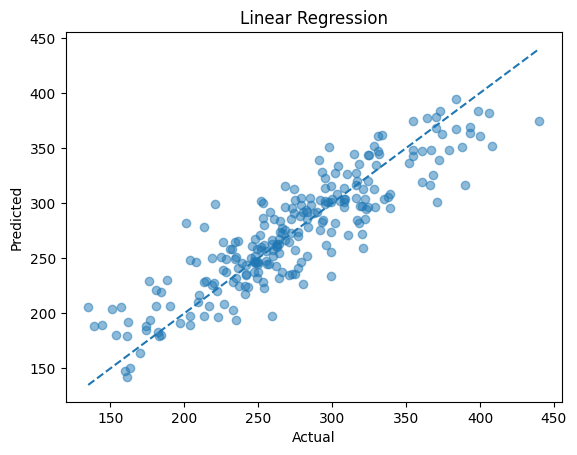

Random Forest | RMSE: 31.04 | MAE: 24.99


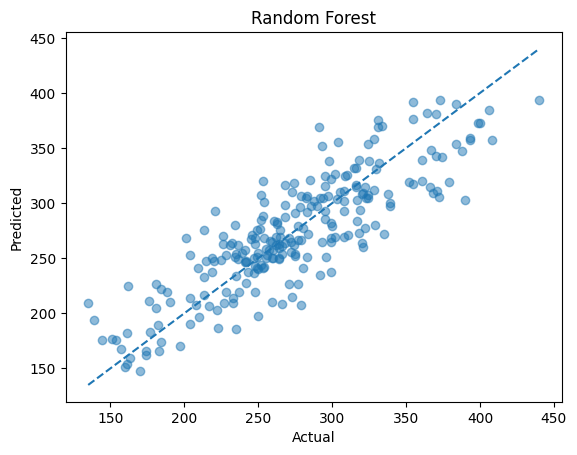


Top 5 Important Features:
is_festival            0.173178
store_size_small       0.172162
location_type_urban    0.113357
day_of_week            0.087928
is_weekend             0.068761
dtype: float64


In [23]:
# Task 4 : Model Training and Evaluation

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

models = [
    ("Linear Regression", LinearRegression()),
    ("Random Forest", RandomForestRegressor(random_state=42))
]

for name, model in models:

    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    print(f"{name} | RMSE: {np.sqrt(mean_squared_error(y_test, pred)):.2f} | MAE: {mean_absolute_error(y_test, pred):.2f}")

    plt.scatter(y_test, pred, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], '--')
    plt.title(name)
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.show()

# Feature Importance

rf_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

rf_pipe.fit(X_train, y_train)

# Get correct feature names after encoding
cat_features = rf_pipe.named_steps['preprocessor'] \
    .named_transformers_['ohe'] \
    .get_feature_names_out(cat_cols)

all_features = list(cat_features) + num_cols

importance = rf_pipe.named_steps['model'].feature_importances_

feat_imp = pd.Series(importance, index=all_features).sort_values(ascending=False)

print("\nTop 5 Important Features:")
print(feat_imp.head(5))